> # ***Introduction***

Metabolic dysfunction-associated steatotic liver disease (MASLD), formerly known as non-alcoholic fatty liver disease (NAFLD), is one of the most common chronic liver conditions worldwide, affecting an estimated 25–30% of the global population. It is characterized by excessive fat accumulation in the liver (hepatic steatosis) in the absence of significant alcohol consumption, and is closely linked to obesity, type 2 diabetes, and metabolic syndrome.

MASLD exists on a spectrum of severity — from simple steatosis (fat accumulation with minimal inflammation) to steatohepatitis, fibrosis, and eventually cirrhosis if left untreated. Early and accurate detection is essential, since the disease is often asymptomatic in its initial stages but can progress silently toward serious liver damage.

Two complementary diagnostic tools are commonly used to assess MASLD:

Ultrasound imaging, which provides a non-invasive visual assessment of liver echogenicity and is typically used to grade the severity of steatosis (e.g., Grade 1: mild, Grade 2: moderate, Grade 3: severe).
FibroScan (transient elastography), which measures liver stiffness and fat content to estimate two key clinical parameters:
Fibrosis stage (ranging from F0/F1 – no or minimal fibrosis, to advanced fibrosis stages), reflecting the degree of liver scarring.
Steatosis stage (ranging from S0 – normal, to higher grades), reflecting the extent of fat accumulation.
About This Dataset

This notebook combines two complementary sources of data for MASLD patients:

Radiology dataset — a collection of liver ultrasound images organized by steatosis grade (Grade_1, Grade_2, Grade_3), each paired with a corresponding segmentation mask highlighting the region of interest in the liver.
FibroScan results — clinical measurements for each patient, including fibrosis stage and steatosis stage, obtained through transient elastography.

By linking the imaging data with the corresponding clinical FibroScan measurements for each patient, this combined dataset enables the development of models that connect visual liver characteristics with quantitative clinical severity indicators — supporting research into automated, image-based assessment of MASLD severity as a potential complement to invasive diagnostic procedures such as liver biopsy.

In [1]:
import os 
import cv2
import json
import re
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random
import warnings 
warnings.filterwarnings('ignore')

from collections import defaultdict
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras import losses
from tensorflow.keras import callbacks
from tensorflow.keras import layers
from tensorflow.keras import optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam , Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.layers import Conv2D, MaxPooling2D , GlobalAveragePooling2D,Dropout,BatchNormalization,Input,Flatten,Dense
from tensorflow.keras.applications import EfficientNetB0 ,DenseNet121,ResNet50

from IPython.display import clear_output
!pip install tf_explain
clear_output()

from keras.callbacks import Callback
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
from tf_explain.core.grad_cam import GradCAM

from keras.metrics import MeanIoU

In [2]:
BASE_PATH = "/kaggle/input/datasets/sohailaelsayed/final-masald-dataset/final merge dataset/final merge dataset"
data = []

# Grades
for grade in ["Grade_1", "Grade_2", "Grade_3"]:
    
    radiology_dir = os.path.join(BASE_PATH, grade, "Radiology")
    masks_dir = os.path.join(BASE_PATH, grade, "Masks")
    
    radiology_files = os.listdir(radiology_dir)
    
    for radiology_file in radiology_files:
        
        if not radiology_file.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
    
        image_id = os.path.splitext(radiology_file)[0]
        
        mask_file = image_id + ".png"
        mask_path = os.path.join(masks_dir, mask_file)
        
        radiology_path = os.path.join(radiology_dir, radiology_file)
        
        if os.path.exists(mask_path):
            
            data.append({
                "image_path": radiology_path,
                "mask_path": mask_path,
                "grade": grade
            })

df = pd.DataFrame(data)

print("Number of samples:", len(df))
df.head()

Number of samples: 2031


,image_path,mask_path,grade
0,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1
1,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1
2,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1
3,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1
4,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1


In [3]:
fibroscan = pd.read_csv("/kaggle/input/datasets/sohailaelsayed/final-masald-dataset/final merge dataset/final merge dataset/fibroscan_results.csv")
fibroscan

,image_name,stage_fibrosis,stage_steatosis,Unnamed: 3
0,organized_dataset1_Amr_abdel_moniem_fibroscan.jpg,F0-F1 (No/minimal fibrosis),S0 (Normal),NaN
1,organized_dataset1_Badyra_Mahmoud_fibroscan.jpg,F0-F1 (No/minimal fibrosis),S0 (Normal),NaN
2,organized_dataset1_Doaa_mohamed_fibroscan.jpg,F0-F1 (No/minimal fibrosis),S0 (Normal),NaN
3,organized_dataset1_fatma_ashraf_fibroscan.jpg,F0-F1 (No/minimal fibrosis),S2 (Moderate),NaN
4,organized_dataset1_Ghada_Nabil_fibroscan.jpg,F0-F1 (No/minimal fibrosis),S2 (Moderate),NaN
...,...,...,...,...
137,organized_dataset3_mohram_hussenen_fibroscan.jpeg,F3-F4 (Advanced fibrosis),S3 (Severe),NaN
138,organized_dataset3_mona_zeinelabdin_fibroscan....,F0-F1 (No/minimal fibrosis),S0 (Normal),NaN
139,organized_dataset4_Eftrag_AbdelJeleel_fibrosca...,F0-F1 (No/minimal fibrosis),S0 (Normal),NaN
140,organized_dataset4_Farha_ahmad_fibroscan.jpg,F0-F1 (No/minimal fibrosis),S3 (Severe),NaN


In [4]:
df['image_path'][0]

'/kaggle/input/datasets/sohailaelsayed/final-masald-dataset/final merge dataset/final merge dataset/Grade_1/Radiology/organized_dataset1_fatma_ashraf_07.jpg'

In [5]:
def extract_id_from_image_path(path):
    filename = os.path.splitext(os.path.basename(path))[0]  
    base_id = re.sub(r'_\d+$', '', filename)
    return base_id

df["patient_id"] = df["image_path"].apply(extract_id_from_image_path)

def extract_id_from_image_name(name):
    filename = os.path.splitext(name)[0]  
    base_id = re.sub(r'_fibroscan$', '', filename)
    return base_id


fibroscan["patient_id"] = fibroscan["image_name"].apply(extract_id_from_image_name)

df["patient_id"] = df["patient_id"].str.lower()
fibroscan["patient_id"] = fibroscan["patient_id"].str.lower()


merged_df = pd.merge(df, fibroscan, on="patient_id", how="inner")

print("Number of merged samples:", len(merged_df))
merged_df.head()

Number of merged samples: 1850


,image_path,mask_path,grade,patient_id,image_name,stage_fibrosis,stage_steatosis,Unnamed: 3
0,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1,organized_dataset1_fatma_ashraf,organized_dataset1_fatma_ashraf_fibroscan.jpg,F0-F1 (No/minimal fibrosis),S2 (Moderate),NaN
1,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1,organized_dataset4_gamalat_abdel_moniem,organized_dataset4_Gamalat_abdel_moniem_fibros...,F2-F3 (Significant fibrosis),S0 (Normal),NaN
2,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1,organized_dataset3_sanaa_mohamed,organized_dataset3_sanaa_mohamed_fibroscan.jpeg,F0-F1 (No/minimal fibrosis),S0 (Normal),NaN
3,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1,organized_dataset2_aisha_ramadan,organized_dataset2_Aisha_ramadan_fibroscan.jpg,F0-F1 (No/minimal fibrosis),S2 (Moderate),NaN
4,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1,organized_dataset4_hamedya_said,organized_dataset4_Hamedya_said_fibroscan.jpg,F3-F4 (Advanced fibrosis),S0 (Normal),NaN


In [6]:
def norm(x):
    x = x.lower().strip()
    x = re.sub(r'\s+', '_', x)
    x = re.sub(r'_+', '_', x)
    return x

df["patient_id_norm"] = df["patient_id"].apply(norm)
fibroscan["patient_id_norm"] = fibroscan["patient_id"].apply(norm)
corrections = {
    "organized_dataset5_soilman_soady": "organized_dataset5_soliman_soady",
    "organized_dataset5_set_elahl_elayed": "organized_dataset5_set_elahl_elyed",
    "organized_dataset5_soad_mohamed_metwally": "organized_dataset5_soad_mohamed",
}
df["patient_id_norm"] = df["patient_id_norm"].replace(corrections)
merged_df = pd.merge(df, fibroscan, on="patient_id_norm", how="inner", suffixes=("", "_fibro"))
print("Number of merged samples:", len(merged_df))
unmatched = df[~df["patient_id_norm"].isin(fibroscan["patient_id_norm"])]
print("\nUnmatched images (won't have fibroscan data):", len(unmatched))
print(unmatched["image_path"].apply(lambda p: p.split('/')[-1]).value_counts().head(20))

Number of merged samples: 2031

Unmatched images (won't have fibroscan data): 0
Series([], Name: count, dtype: int64)


In [7]:
merged_df.columns

Index(['image_path', 'mask_path', 'grade', 'patient_id', 'patient_id_norm',
       'image_name', 'stage_fibrosis', 'stage_steatosis', 'Unnamed: 3',
       'patient_id_fibro'],
      dtype='object')

In [8]:
df = merged_df.copy()
df.drop(['grade', 'patient_id', 'patient_id_norm',
       'image_name','stage_fibrosis', 'patient_id_fibro','Unnamed: 3'],axis=1, inplace=True)

In [9]:
df.columns

Index(['image_path', 'mask_path', 'stage_steatosis'], dtype='object')

In [10]:
df.loc[df['stage_steatosis']=='S1(Mild)','stage_steatosis'] = 'S1 (Mild)'

In [11]:
df['stage_steatosis'].unique()

array(['S2 (Moderate)', 'S0 (Normal)', 'S3 (Severe)', 'S1 (Mild)'],
      dtype=object)

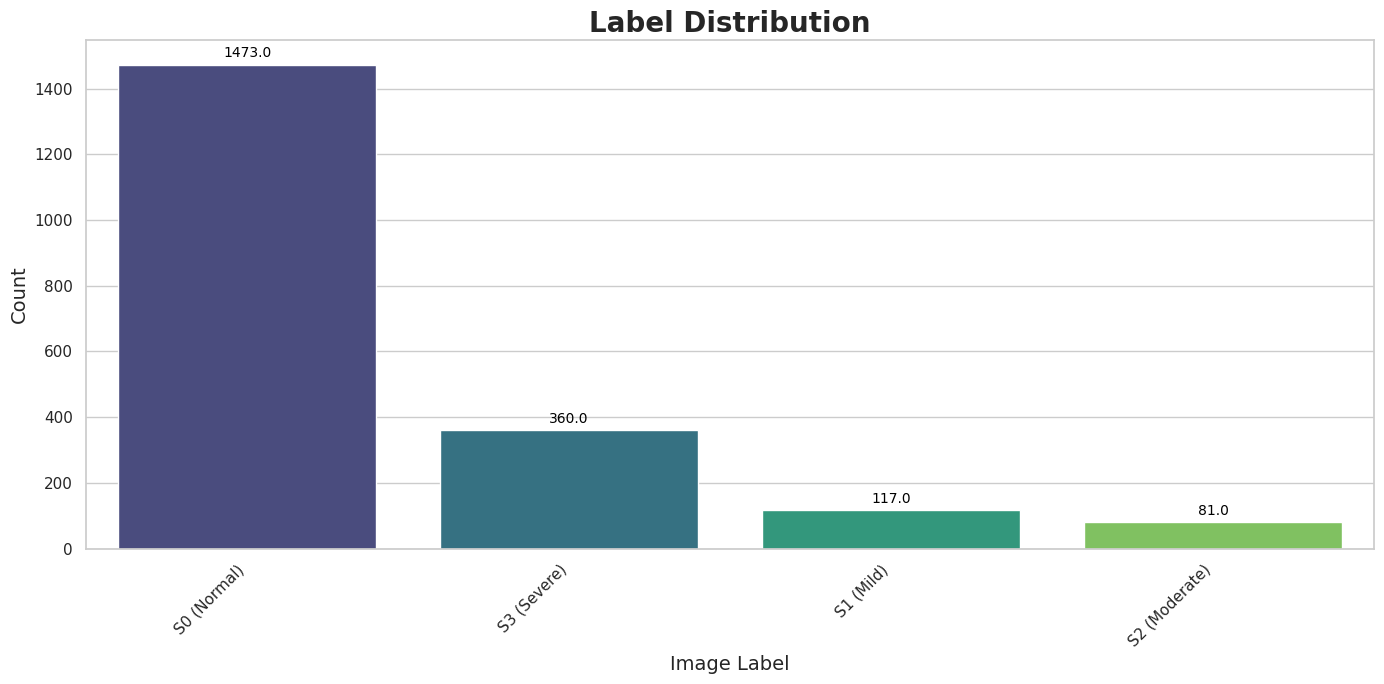

In [12]:
sns.set(style="whitegrid")
plt.figure(figsize=(14, 7))
ax = sns.countplot(data=df, x='stage_steatosis', palette='viridis', order=df['stage_steatosis'].value_counts().index)

plt.title("Label Distribution", fontsize=20, fontweight='bold')
plt.xlabel("Image Label", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 8),
                textcoords='offset points')
plt.tight_layout()
plt.show()

> # ***Show Sample of Data*** 

In [13]:
df_s0 = df[df['stage_steatosis']=='S0 (Normal)'].head(1)
df_s1 = df[df['stage_steatosis']=='S1 (Mild)'].head(1)
df_s2 = df[df['stage_steatosis']=='S2 (Moderate)'].head(1)
df_s3 = df[df['stage_steatosis']=='S3 (Severe)'].head(1)

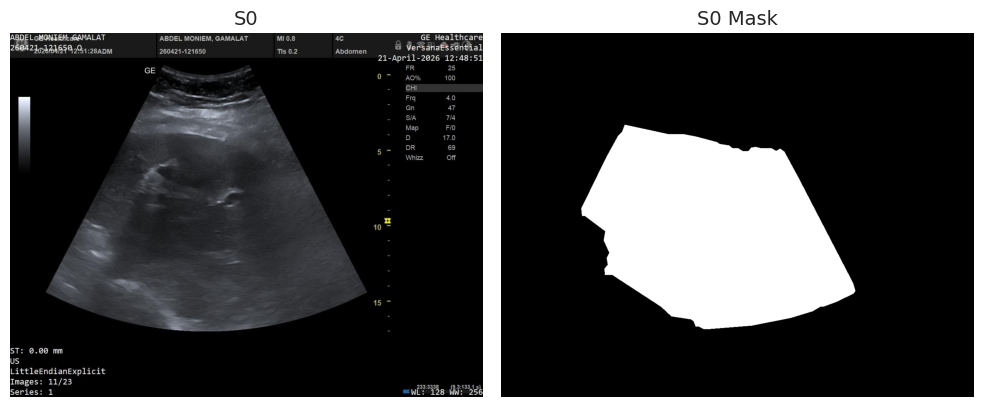

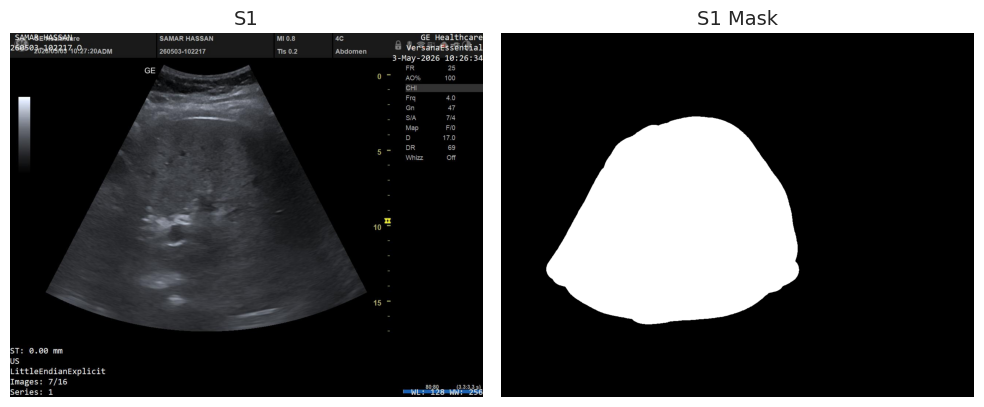

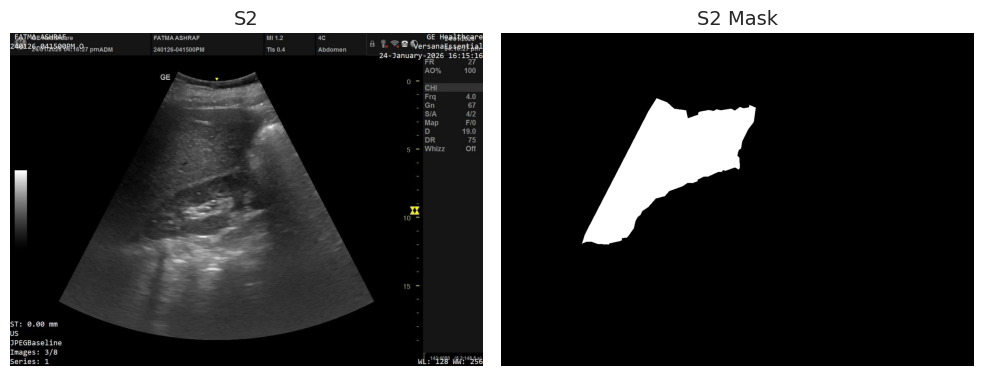

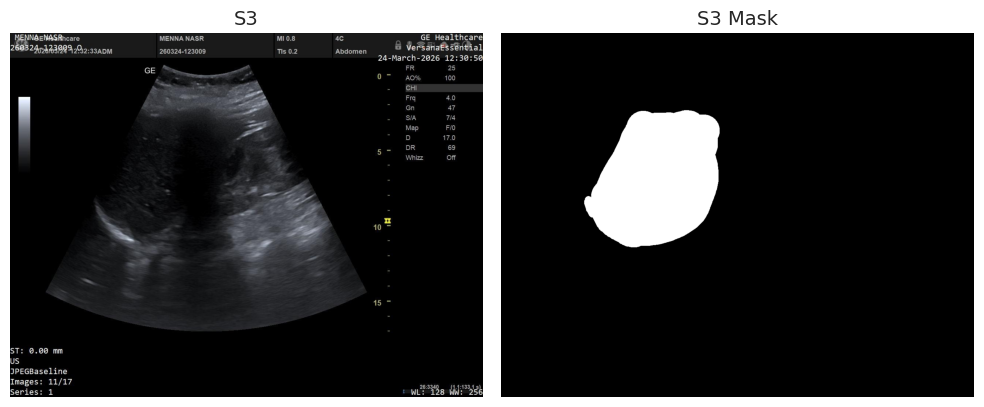

In [14]:
stage_steatosis = {
    "S0": df_s0,
    "S1": df_s1,
    "S2": df_s2,
    "S3": df_s3
}

for steatosis_name, df_steatosis in stage_steatosis.items():

    plt.figure(figsize=(10, 5))
    row = df_steatosis.iloc[0]
    img = Image.open(row["image_path"])
    mask_path = row["mask_path"]

    if isinstance(mask_path, str):
        mask = Image.open(mask_path)
    else:
        mask = None
        
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(steatosis_name, fontsize=14)
    plt.subplot(1, 2, 2)

    if mask is not None:
        plt.imshow(mask, cmap="gray")
        plt.title(f"{steatosis_name} Mask", fontsize=14)
    else:
        plt.title("No Mask")

    plt.axis("off")

    plt.tight_layout()
    plt.show()

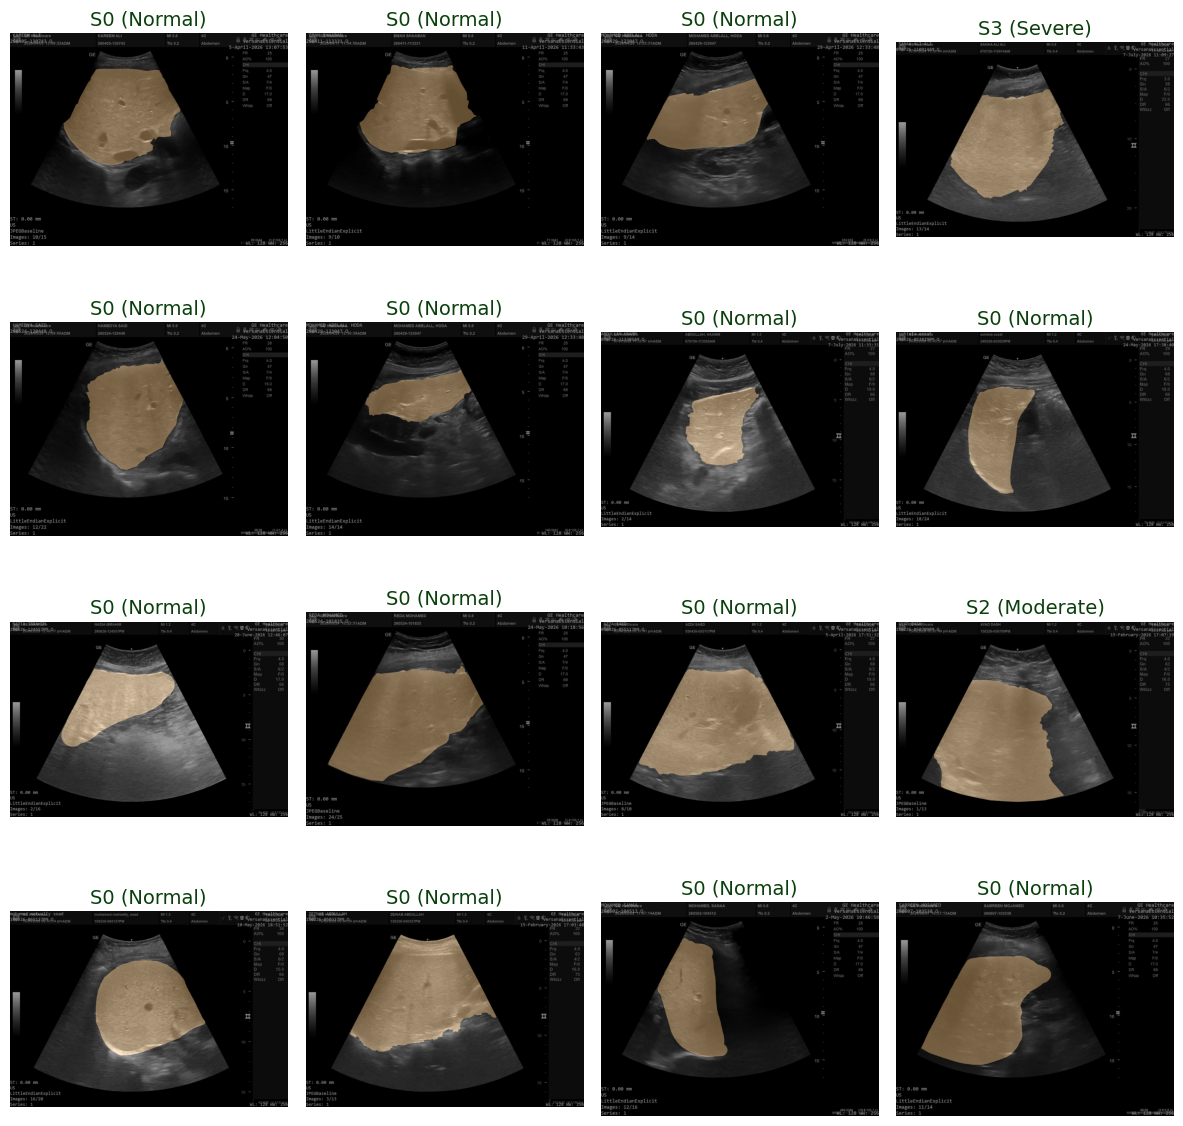

In [15]:
df = df.sample(frac=1).reset_index(drop=True)
plt.figure(figsize=(12, 12))

for i in range(16):
    img_path = df.iloc[i]['image_path']
    img = np.array(Image.open(img_path).convert("L"))
    mask_path = df.iloc[i]['mask_path']

    if isinstance(mask_path, list) and len(mask_path) > 0:
        mask_path = mask_path[0]

    if mask_path is not None:
        mask = np.array(Image.open(mask_path).convert("L"))
    else:
        mask = None
        
    plt.subplot(4, 4, i + 1)

    plt.imshow(img, cmap="gray")
    if mask is not None:
        plt.imshow(mask, cmap="copper", alpha=0.4)
    label_name = df.iloc[i]['stage_steatosis']
    plt.title(label_name, color='#0A400C', fontsize=14)

    plt.axis("off")

plt.tight_layout()
plt.show()

> # ***HyperParameters*** 

In [16]:
batchsize    = 32
image_height = 224
image_width  = 224
num_classes  = 4
epochs       = 65

In [17]:
def load_image_mask(image_path, mask_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (224, 224))
    image = tf.cast(image, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, (224, 224))
    mask = tf.cast(mask, tf.float32) / 255.0

    return image, mask, label

In [18]:
train_df, validation_df = train_test_split(
    df,
    test_size=0.1,
    shuffle=True,
    random_state=42,
    stratify=df['stage_steatosis']
)

In [19]:
print("Train:", len(train_df))
print("Validation:", len(validation_df))

print("\nTrain distribution:")
print(train_df['stage_steatosis'].value_counts(normalize=True))

print("\nValidation distribution:")
print(validation_df['stage_steatosis'].value_counts(normalize=True))

Train: 1827
Validation: 204

Train distribution:
stage_steatosis
S0 (Normal)      0.725233
S3 (Severe)      0.177340
S1 (Mild)        0.057471
S2 (Moderate)    0.039956
Name: proportion, dtype: float64

Validation distribution:
stage_steatosis
S0 (Normal)      0.725490
S3 (Severe)      0.176471
S1 (Mild)        0.058824
S2 (Moderate)    0.039216
Name: proportion, dtype: float64


In [20]:
class_names = sorted(df['stage_steatosis'].unique())
class_to_idx = {
    name: idx for idx, name in enumerate(class_names)
}
train_df['label_id'] = train_df['stage_steatosis'].map(class_to_idx)
validation_df['label_id'] = validation_df['stage_steatosis'].map(class_to_idx)

In [21]:
def augment(image, mask,label):
    seed = tf.random.uniform(
        [2],
        maxval=100000,
        dtype=tf.int32
    )

    image = tf.image.stateless_random_flip_left_right(
        image,
        seed=seed
    )

    mask = tf.image.stateless_random_flip_left_right(
        mask,
        seed=seed
    )

    return image, mask , label

> # Data Augmentation

On-the-fly augmentation was applied using a random horizontal flip to both the image and its corresponding mask with the same seed, ensuring proper alignment.

This approach does not create or store additional images, so it **saves storage space** while providing different image variations across training epochs. It is a **simple, lightweight, and storage-efficient** augmentation technique that helps reduce overfitting.


In [22]:
def combine_image_mask(image, mask, label):
    combined = tf.concat([image, mask], axis=-1)

    return combined, label

In [23]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_df['image_path'].values,
        train_df['mask_path'].values,
        train_df['label_id'].values
    )
)

train_ds = train_ds.map(
    load_image_mask,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.map(
    augment,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.map(
    combine_image_mask,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.batch(batchsize)

train_ds = train_ds.prefetch(
    tf.data.AUTOTUNE
)

I0000 00:00:1790460183.865113      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790460183.868273      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [24]:
validation_ds = tf.data.Dataset.from_tensor_slices(
    (
        validation_df['image_path'].values,
        validation_df['mask_path'].values,
        validation_df['label_id'].values
    )
)

validation_ds = validation_ds.map(
    load_image_mask,
    num_parallel_calls=tf.data.AUTOTUNE
)

validation_ds = validation_ds.map(
    combine_image_mask,
    num_parallel_calls=tf.data.AUTOTUNE
)

validation_ds = validation_ds.batch(batchsize)

validation_ds = validation_ds.prefetch(
    tf.data.AUTOTUNE
)

In [25]:
print("Train samples:", len(train_df))
print("Validation samples:", len(validation_df))

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(validation_ds).numpy())

print("Batch size:", batchsize)

Train samples: 1827
Validation samples: 204
Train batches: 58
Validation batches: 7
Batch size: 32


In [26]:
lr_callback   = callbacks.ReduceLROnPlateau(monitor= 'val_accuracy',factor = 0.1,patience=5)
stop_callback = callbacks.EarlyStopping(monitor= 'val_accuracy',patience=8)
model_ckpt = callbacks.ModelCheckpoint("densenet121_model.h5",save_best_only=True,monitor="val_accuracy",mode="max")

> # ***DenseNet121***

In [27]:
def build_model():
    inputs = layers.Input(
        shape=(image_width, image_height, 4),
        name="image_mask_input"
    )
    x = layers.Conv2D(
        filters=3,
        kernel_size=1,
        padding='same',
        name='convert_4_to_3'
    )(inputs)

    #DenseNet121
    base_model = DenseNet121(
        include_top=False,
        weights='imagenet',
        input_shape=(image_width, image_height, 3)
    )

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D(name='avg_pool')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4, name='top_dropout')(x)

    output = layers.Dense(
        num_classes,
        activation='softmax',
        name='pred'
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=output,
        name='DenseNET121_Image_Mask'
    )

    optimizer = optimizers.Adam(
        learning_rate=1e-3
    )

    loss = losses.SparseCategoricalCrossentropy()

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    model.summary()

    return model

In [28]:
model = build_model()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "DenseNET121_Image_Mask"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_mask_input (InputLayer)   │ (None, 224, 224, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convert_4_to_3 (Conv2D)         │ (None, 224, 224, 3)    │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avg_pool                        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_dropout (Dropout)           │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred (Dense)                    │ (None, 4)              │         4,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,045,715 (26.88 MB)

 Trainable params: 6,960,019 (26.55 MB)

 Non-trainable params: 85,696 (334.75 KB)

In [29]:
history = model.fit(
    train_ds,
    validation_data = validation_ds,
    callbacks = [lr_callback,model_ckpt],
    epochs = epochs,
    verbose =1
)

Epoch 1/65


2026-09-26 22:04:31.473532: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 22:04:31.621943: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1790460360.513759      80 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.4520 - loss: 1.5970

2026-09-26 22:06:33.134843: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 22:06:33.275662: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 22:08:47.168165: E external/local_xla/xla/service/slow_operation_alarm.cc:73] 
********************************
[Compiling module a_inference_one_step_on_data_80543__.54575] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4537 - loss: 1.5911   

...

58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 315ms/step - accuracy: 0.9595 - loss: 0.1145 - val_accuracy: 0.9314 - val_loss: 0.2879 - learning_rate: 0.0010
Epoch 9/65
58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 296ms/step - accuracy: 0.9693 - loss: 0.0938 - val_accuracy: 0.8382 - val_loss: 1.0325 - learning_rate: 0.0010
Epoch 10/65
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.9769 - loss: 0.0572

58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 316ms/step - accuracy: 0.9836 - loss: 0.0453 - val_accuracy: 0.9510 - val_loss: 0.1589 - learning_rate: 0.0010
Epoch 11/65
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.9841 - loss: 0.0440

58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 315ms/step - accuracy: 0.9836 - loss: 0.0476 - val_accuracy: 0.9559 - val_loss: 0.1390 - learning_rate: 0.0010
Epoch 12/65
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.9896 - loss: 0.0310

58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 317ms/step - accuracy: 0.9929 - loss: 0.0247 - val_accuracy: 0.9853 - val_loss: 0.0310 - learning_rate: 0.0010
Epoch 13/65
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.9943 - loss: 0.0176

58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 316ms/step - accuracy: 0.9929 - loss: 0.0199 - val_accuracy: 0.9951 - val_loss: 0.0231 - learning_rate: 0.0010
Epoch 14/65
58/58 ━━━━━━━━━━━━━━━━━━━━ 17s 296ms/step - accuracy: 0.9967 - loss: 0.0113 - val_accuracy: 0.9951 - val_loss: 0.0111 - learning_rate: 0.0010
Epoch 15/65
58/58 ━━━━━━━━━━━━━━━━━━━━ 17s 296ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.9951 - val_loss: 0.0179 - learning_rate: 0.0010
Epoch 16/65
58/58 ━━━━━━━━━━━━━━━━━━━━ 20s 341ms/step - accuracy: 1.0000 - loss: 4.1608e-04 - val_accuracy: 0.9951 - val_loss: 0.0112 - learning_rate: 0.0010
Epoch 17/65
58/58 ━━━━━━━━━━━━━━━━━━━━ 17s 295ms/step - accuracy: 1.0000 - loss: 4.8868e-04 - val_accuracy: 0.9951 - val_loss: 0.0127 - learning_rate: 0.0010
Epoch 18/65
58/58 ━━━━━━━━━━━━━━━━━━━━ 17s 296ms/step - accuracy: 1.0000 - loss: 2.9341e-04 - val_accuracy: 0.9951 - val_loss: 0.0129 - learning_rate: 0.0010
Epoch 19/65
58/58 ━━━━━━━━━━━━━━━━━━━━ 17s 297ms/step - accuracy: 1.0000 - l

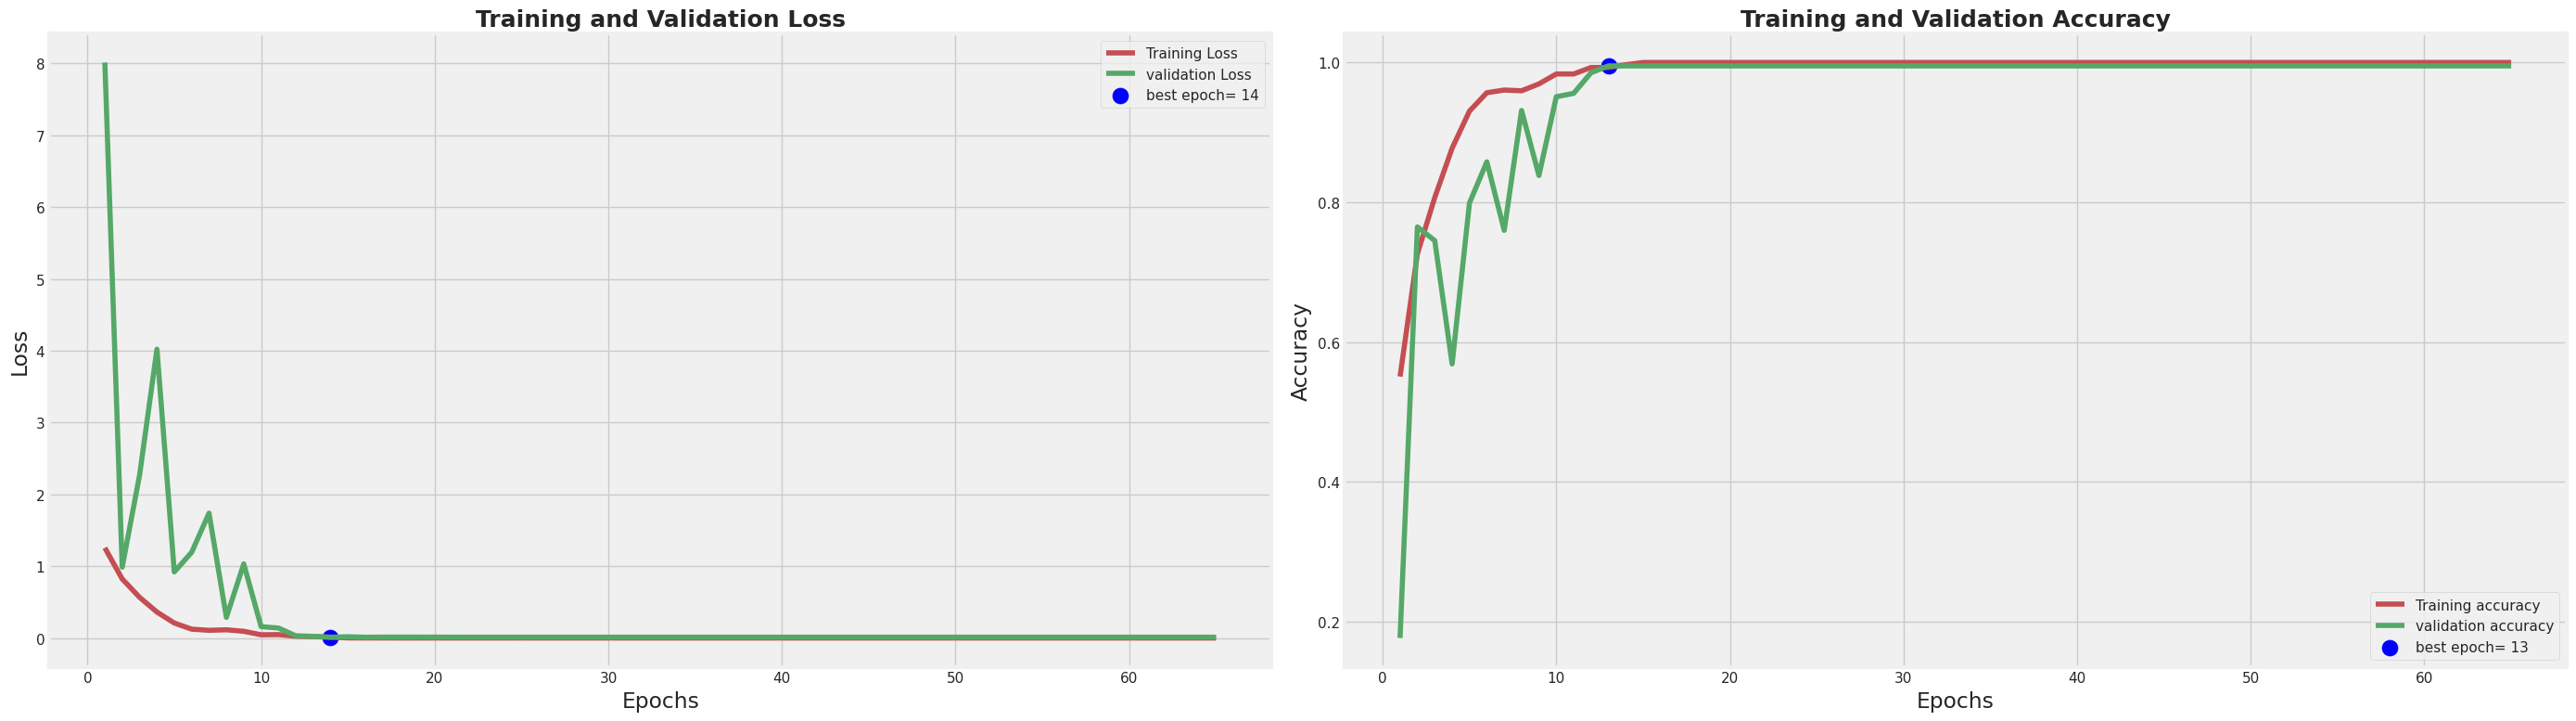

In [30]:
tr_acc   = history.history['accuracy']
tr_loss  = history.history['loss']
val_acc  = history.history['val_accuracy']
val_loss = history.history['val_loss']

idx_loss   = np.argmin(val_loss)
val_lowest = val_loss[idx_loss]
idx_acc    = np.argmax(val_acc)
val_highest= val_acc[idx_acc]

Epochs =[i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(idx_loss + 1)}'
acc_label = f'best epoch= {str(idx_acc + 1)}'

plt.figure(figsize=(28,8))
plt.style.use("fivethirtyeight")

plt.subplot(1,2,1)
plt.plot(Epochs,tr_loss,'r',label='Training Loss')
plt.plot(Epochs,val_loss,'g',label='validation Loss')
plt.scatter(idx_loss+1,val_lowest,s=150,c='blue',label= loss_label)
plt.title('Training and Validation Loss',fontweight='bold',fontsize=18)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(Epochs,tr_acc,'r',label='Training accuracy')
plt.plot(Epochs,val_acc,'g',label='validation accuracy')
plt.scatter(idx_acc+1,val_highest,s=150,c='blue',label= acc_label)
plt.title('Training and Validation Accuracy',fontweight='bold',fontsize=18)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig(
    "training_curves_DenseNet121.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [31]:
y_test = []
y_pred = []

for images, labels in validation_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_pred.extend(preds)
    y_test.extend(labels.numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


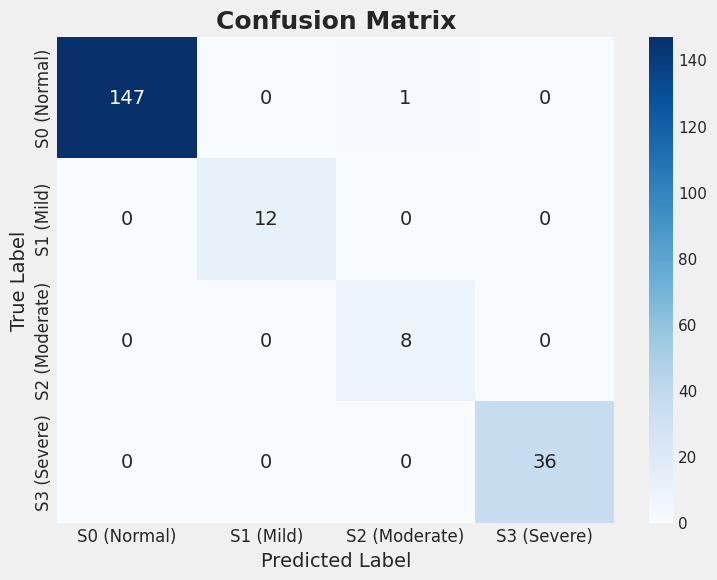

 Classification Report:

               precision    recall  f1-score   support

  S0 (Normal)       1.00      0.99      1.00       148
    S1 (Mild)       1.00      1.00      1.00        12
S2 (Moderate)       0.89      1.00      0.94         8
  S3 (Severe)       1.00      1.00      1.00        36

     accuracy                           1.00       204
    macro avg       0.97      1.00      0.98       204
 weighted avg       1.00      1.00      1.00       204

 Accuracy Score: 0.9951


In [32]:
con = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))

sns.heatmap(con, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix', fontsize=18, weight='bold')
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig(
    "Confusion_matrix_DenseNet121.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(" Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))
print(f" Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

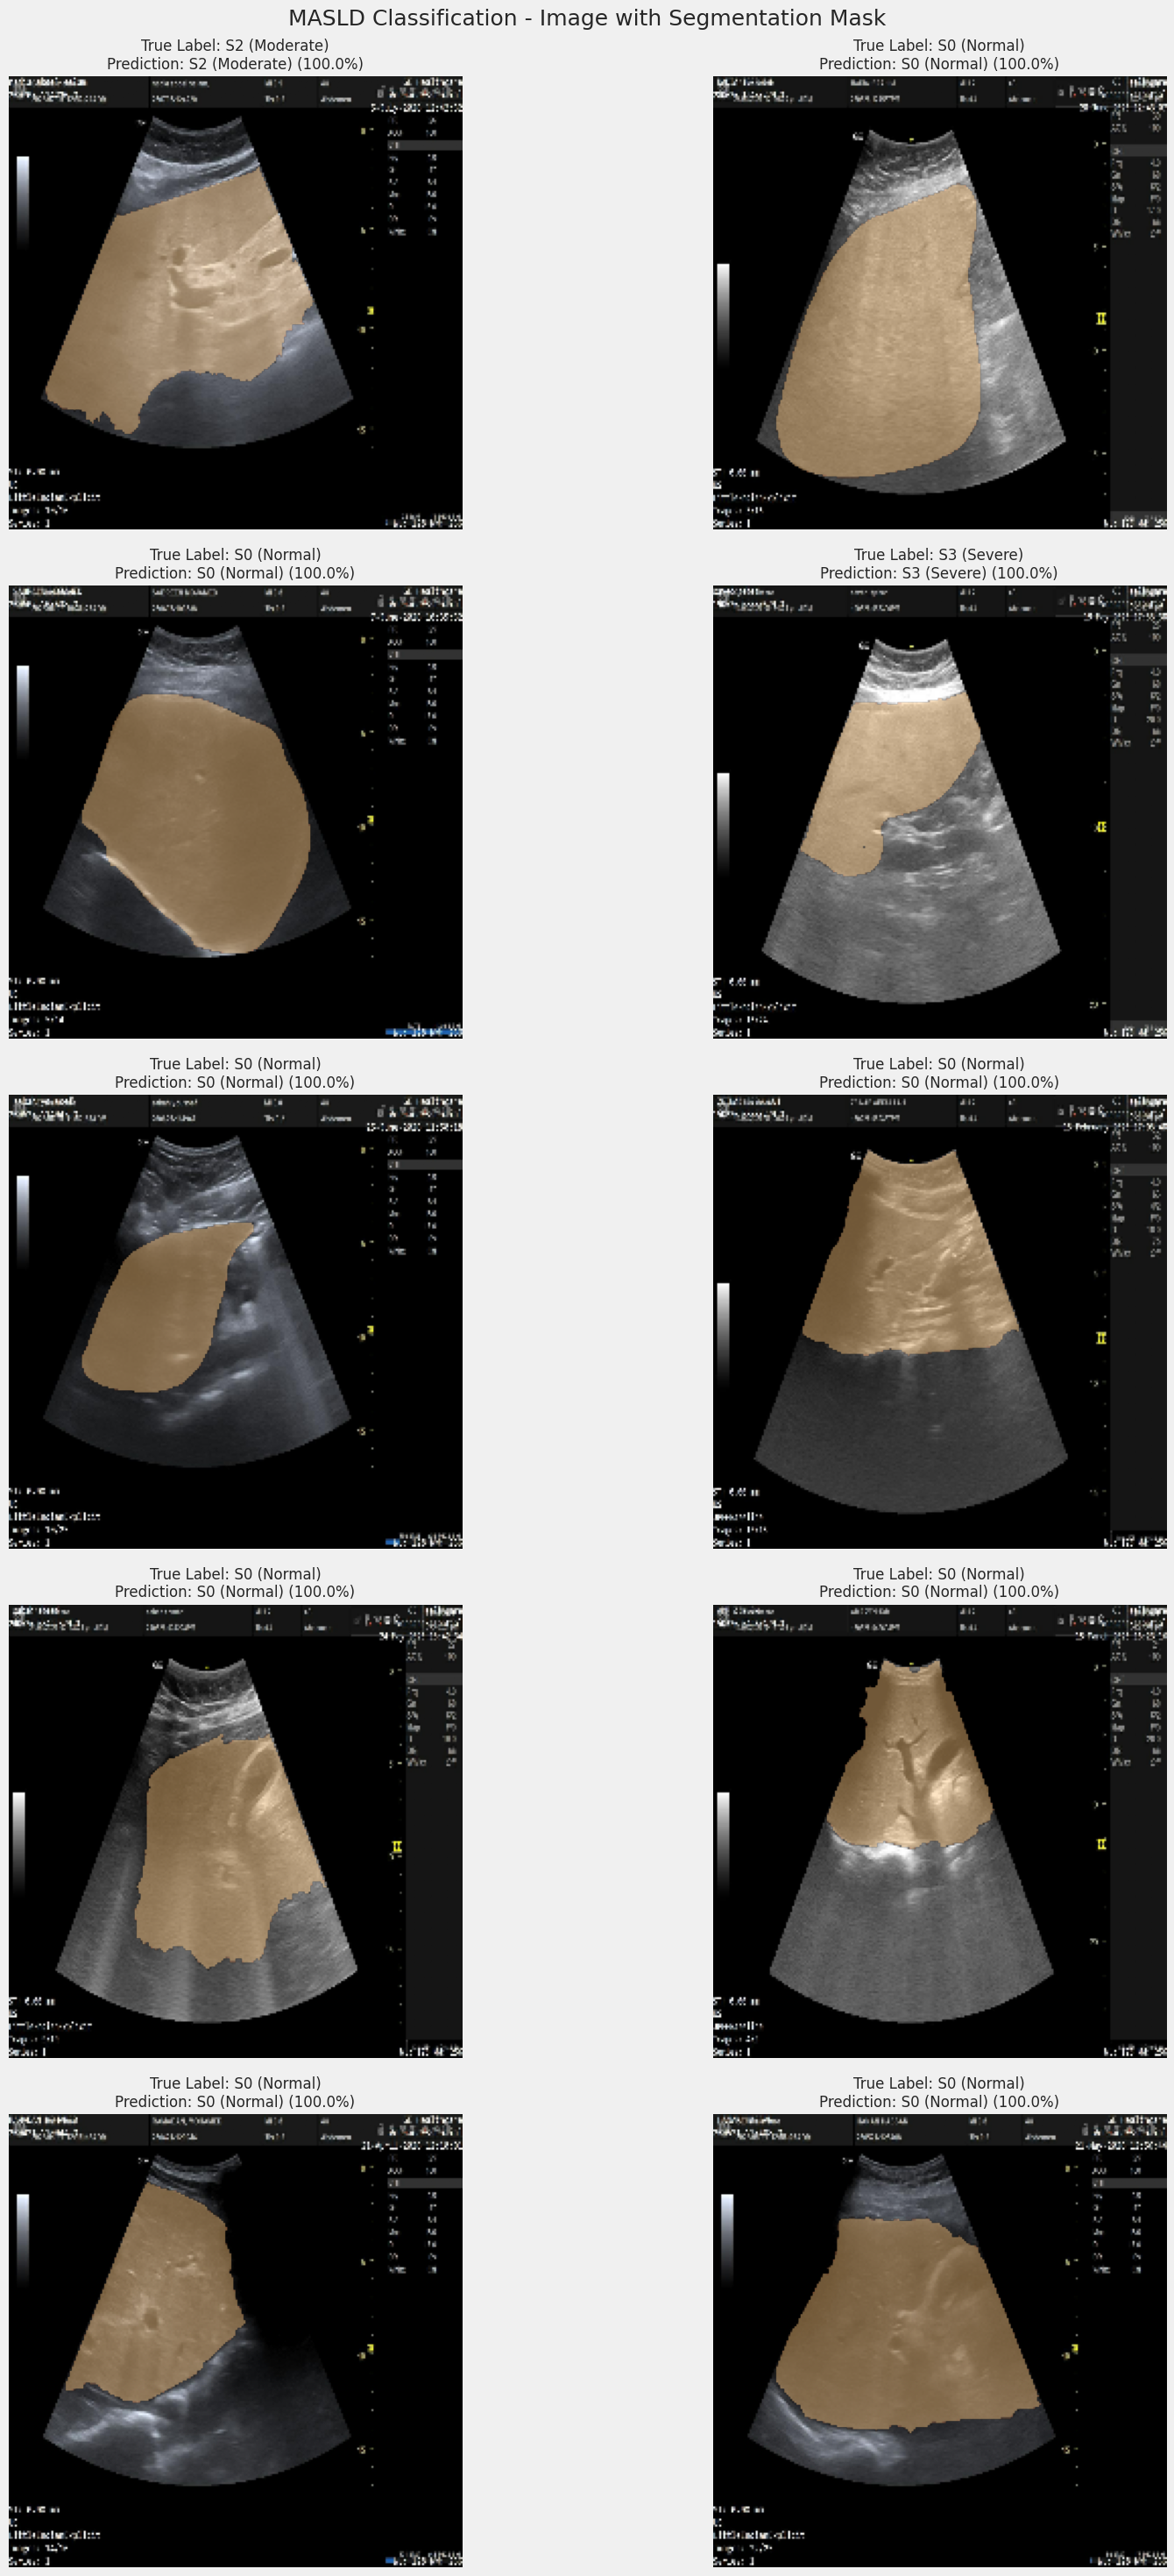

In [33]:
num_images = 10

samples = validation_df.sample(
    n=min(num_images, len(validation_df)),
    random_state=42
)

fig, axes = plt.subplots(
    5, 2,
    figsize=(20, 30)
)

axes = axes.flatten()

for i, (_, row) in enumerate(samples.iterrows()):
    image, mask, label = load_image_mask(
        tf.constant(row["image_path"]),
        tf.constant(row["mask_path"]),
        tf.constant(row["label_id"])
    )

    image = image.numpy()
    mask = mask.numpy()

    # Remove channel dimension from mask
    mask = np.squeeze(mask)
    combined = np.concatenate(
        [image, mask[..., np.newaxis]],
        axis=-1
    )
    prediction = model.predict(
        np.expand_dims(combined, axis=0),
        verbose=0
    )

    predicted_id = np.argmax(prediction[0])
    predicted_label = class_names[predicted_id]
    true_label = row["stage_steatosis"]
    confidence = prediction[0][predicted_id] * 100
    axes[i].imshow(image)
    # Show only mask pixels
    masked = np.ma.masked_where(
        mask <= 0,
        mask
    )

    axes[i].imshow(
        masked,
        cmap="copper",
        alpha=0.45
    )
    axes[i].set_title(
        f"True Label: {true_label}\n"
        f"Prediction: {predicted_label} "
        f"({confidence:.1f}%)",
        fontsize=12
    )
    axes[i].axis("off")
fig.suptitle(
    "MASLD Classification - Image with Segmentation Mask\n",
    fontsize=18
)

plt.tight_layout()
plt.savefig(
    "MASLD_Classification_stage_steatosis.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

> # ***Save Model*** 

In [34]:
model.save("final_DenseNet121.h5")